# Gaussian Process Regression

This demo shows how to use the GaussianProcessRegressor class to regress the efficiency of three-jet events with MET < 50, given the following nuisance parameters:
- $\nu^{j_1}_{inner}$: jet energy scale of the leading jet (j1) with eta < 1
- $\nu^{j_1}_{outer}$: jet energy scale of the leading jet (j1) with eta >= 1
- $\nu^{j_{2,3}}_{inner}$: jet energy scale of the two softer jets (j2 & j3) with average eta < 1
- $\nu^{j_{2,3}}_{outer}$: jet energy scale of the two softer jets (j2 & j3) with average eta >= 1

And the following selection criteria:
- (j1_pT/$\nu^{j_1}$ > 200 GeV) & (j2_pT/$\nu^{j_{2,3}}$ < 200 GeV)
- MET < 50 GeV

The functions used to calculate the efficiency and MET can be found in obj_functions.py  
Derivative information is used to improve the regression results. 

**Note: to speed things up, we're only using 1K jets in this demo.**

In [1]:
import sys 
import numpy as np
import matplotlib.pyplot as plt
import itertools
import h5py

from multiprocessing import Pool, cpu_count

from sklearn.metrics import mean_squared_error

sys.path.append("../../../gpder")
import gpder
from gpder.gaussian_process import GaussianProcessRegressor
from gpder.gaussian_process.kernels import GPKernel, GPKernelDerAware
from gpder.gaussian_process.warpers import GPWarper

from obj_functions import eff_MET50  # Efficiency function
from obj_functions import deff_MET50_sigmoid  # Gradient of eff_MET50 wrt nuJ

from plotting_utils import plot_gp

The s parameter controls the spread of the sigmoids used to compute the gradients. 
Larger s (s>1) will result in smoother sigmoids while smaller s (s<1) will result in steeper sigmoids.

In this demo, we use smooth sigmoids to avoid discontinuities in the gradients.

In [2]:
def deff_MET50_sigmoid_soft(nuJ1_in, nuJ1_out, nuJ23_in, nuJ23_out):
    return deff_MET50_sigmoid(nuJ1_in, nuJ1_out, nuJ23_in, nuJ23_out, s=100)

def eff_MET50_multi(args):
    (nuJ1_in, nuJ1_out, nuJ23_in, nuJ23_out) = args
    return eff_MET50(nuJ1_in, nuJ1_out, nuJ23_in, nuJ23_out)

def deff_MET50_sigmoid_multi(args):
    (nuJ1_in, nuJ1_out, nuJ23_in, nuJ23_out) = args
    return deff_MET50_sigmoid_soft(nuJ1_in, nuJ1_out, nuJ23_in, nuJ23_out)

In [3]:
res = 25
X_lower = 0.5
X_upper = 1.5

# -- test data -- #
# lin = np.linspace(X_lower, X_upper, res)
# nuJ1_in, nuJ1_out, nuJ23_in, nuJ23_out = np.meshgrid(lin, lin, lin, lin)
# X_test = np.vstack((nuJ1_in.flatten(), nuJ1_out.flatten(), 
#                     nuJ23_in.flatten(), nuJ23_out.flatten())).T 
# y_test = Pool(cpu_count()).map(eff_MET50_multi, X_test)
# y_test = np.array(y_test).reshape(-1, 1)
# dX_test = X_test
## dy_test = Pool(cpu_count()).map(deff_MET50_sigmoid_multi, X_test)
## dy_test = np.array(dy_test)

# -- test data -- #
f = h5py.File('dataset_25res.h5', 'r')
X_test = np.array(f['X'])
y_test = np.array(f['y'])
f.close()

To visualize the efficiency, we plot the efficiency as two jet energy scales are varied while the other two are fixed to have a value of 1.

Note: We only test the predictions on the function observations as the derivative observations are too expensive to sample in all X_test locations.

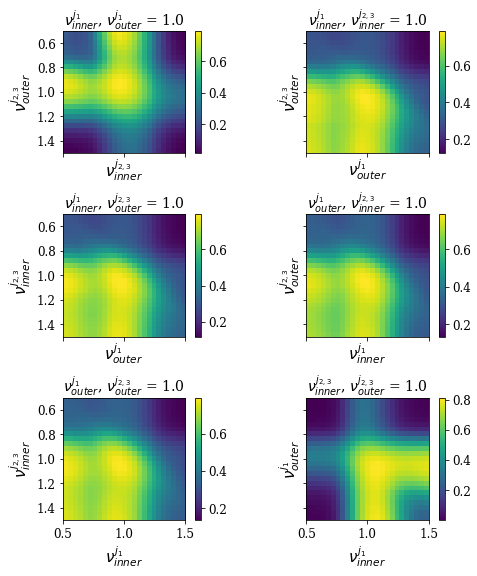

In [4]:
params_labels = [r'$\nu^{j_1}_{inner}$',
                 r'$\nu^{j_1}_{outer}$',
                 r'$\nu^{j_{2, 3}}_{inner}$',
                 r'$\nu^{j_{2, 3}}_{outer}$']
combinations = list(itertools.combinations(np.arange(4), 2))
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = "12"
fig, ax = plt.subplots(3, 2, figsize=(8, 9), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.5, wspace=0.2)
hold_val = 1.0
res = 25
axs = ax.ravel()
quads = []
for i, comb in enumerate(combinations):
    ix = np.where((X_test[:, comb[0]] == hold_val) & (X_test[:, comb[1]] == hold_val))
    y_test_quad = y_test[ix]
    pcm = axs[i].imshow(y_test_quad.reshape(res, res), extent=[X_lower, X_upper, X_upper, X_lower])
    fig.colorbar(pcm, ax=axs[i])
    axs[i].set_title(
        "{}, {} = {}".format(params_labels[comb[0]], params_labels[comb[1]], hold_val), fontsize=14)
    var_params = [i for i in np.arange(4) if i not in comb]
    axs[i].set_xlabel(params_labels[var_params[0]], fontsize=15)
    axs[i].set_ylabel(params_labels[var_params[1]], fontsize=15)
    axs[i].set_xlim(0.5, 1.5)
    axs[i].set_ylim(1.5, 0.5)
    quads.append(y_test_quad)

## Regular GP regression

In [5]:
def get_gp_mu_mse_uncert(gp, X_test, y_test, batch_size=None):
    if batch_size is not None:
        nbatches = int(X_test.shape[0] / batch_size)
        if X_test.shape[0] % batch_size > 0:
            nbatches +=1
        mu, std = np.zeros((len(y_test), 1)), np.zeros((len(y_test)))
        for j in range(nbatches):
            X_test_batch = X_test[j*batch_size : (j+1)*batch_size]
            mu[j*batch_size : (j+1)*batch_size], \
            std[j*batch_size : (j+1)*batch_size] =\
            gp.predict(X_test_batch, return_std=True)
    else:
        mu, std = gp.predict(X_test, return_std=True)
    mse = mean_squared_error(y_test, mu)
    uncert = np.sum(std**2)
    return mu, mse, uncert

In [6]:
params_dicc = {'nuJ1_in': (X_lower, X_upper), 'nuJ1_out': (X_lower, X_upper),
               'nuJ23_in': (X_lower, X_upper), 'nuJ23_out': (X_lower, X_upper)}

params_keys = list(params_dicc.keys())
params_bounds = np.array([params_dicc.get(p) for p in params_dicc])
nparams = len(params_keys)

In [7]:
# -- initial train data -- #
def generate_onaxis_samples(res):
    X_coords = np.linspace(params_bounds[:, 0]+0.2, params_bounds[:, 1]-0.2, res)
    cent_val = (params_bounds[:, 1]+params_bounds[:, 0]) / 2.0
    n = len(X_coords)
    X_grid = np.ones((n*nparams, nparams)) * cent_val
    for i in range(nparams):
        X_grid[i*n:(i+1)*n, i] = X_coords[:, i]
    X_grid_set = set()
    for x in X_grid:
        tupl = tuple(x)
        if tupl not in X_grid_set:
            X_grid_set.add(tupl)
    return np.array(list(X_grid_set))

X_train = generate_onaxis_samples(res=3)
y_train = np.array([
    eff_MET50(X_train[i][0], X_train[i][1], X_train[i][2], X_train[i][3]) for i in range(len(X_train))
    ])
dy_train = np.array([
    deff_MET50_sigmoid(X_train[i][0], X_train[i][1], X_train[i][2], X_train[i][3], s=100) for i in range(len(X_train))
    ])


0.1 * RBF(length_scale=0.2) + WhiteKernel(noise_level=0.001)
MSE:  0.06757520853922692
Uncert:  35442.89585717721


Text(0.45, 0.97, 'Regular GP')

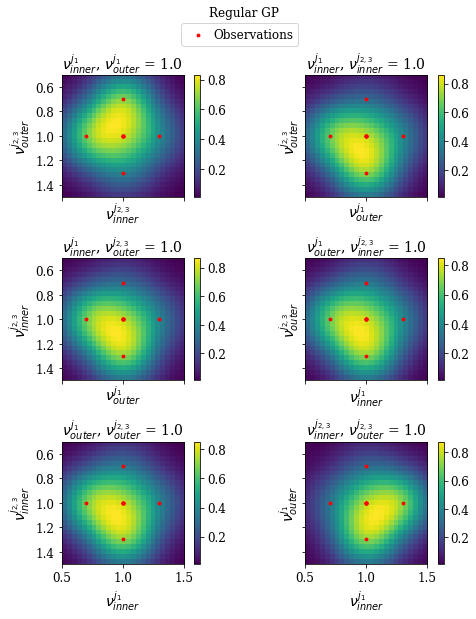

In [8]:
kernel = GPKernel(constant_value=0.1, length_scale=0.2, noise_level=1e-3)
gp_regular = GaussianProcessRegressor(kernel=kernel, optimizer=None, random_state=123)
gp_regular.fit(X=X_train, y=y_train)
print(gp_regular.kernel_)

mu_reg, mse_reg, uncert_reg = get_gp_mu_mse_uncert(gp_regular, X_test, y_test, batch_size=1024)
print("MSE: ", mse_reg)
print("Uncert: ", uncert_reg)

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = "12"
fig, ax = plt.subplots(3, 2, figsize=(8, 9), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.5, wspace=0.2)
hold_val = 1.0
axs = ax.ravel()
for i, comb in enumerate(combinations):
    ix = np.where((X_test[:, comb[0]] == hold_val) & (X_test[:, comb[1]] == hold_val))
    y_test_quad = mu_reg[ix]
    axs[i].scatter(X_train[:, comb[0]], X_train[:, comb[1]], color='r', s=8, label='Observations')
    pcm = axs[i].imshow(y_test_quad.reshape(res, res), extent=[X_lower, X_upper, X_upper, X_lower])
    fig.colorbar(pcm, ax=axs[i])
    axs[i].set_title(
        "{}, {} = {}".format(params_labels[comb[0]], params_labels[comb[1]], hold_val), fontsize=14)
    var_params = [i for i in np.arange(4) if i not in comb]
    axs[i].set_xlabel(params_labels[var_params[0]], fontsize=14)
    axs[i].set_ylabel(params_labels[var_params[1]], fontsize=14)
    axs[i].set_xlim(0.5, 1.5)
    axs[i].set_ylim(1.5, 0.5)
handles, labels = axs[-1].get_legend_handles_labels()
fig.legend(handles=handles, labels=labels,
           loc=(0.38, 0.925), handletextpad=0.3, borderaxespad=0.4)
fig.text(0.45, 0.97, r'Regular GP')

## Derivative-enhanced GPR

And now we use derivative information to aid the GPR.  
For comparison, we use the same five training points and the same random state.

0.1 * DerivativeRBF(length_scale=0.2) + WhiteKernel_X(noise_level=0.001) + WhiteKernel_dX(noise_level=1)
MSE:  0.06498963521068316
Uncert:  32072.207782750047


Text(0.45, 0.97, 'Derivative GP')

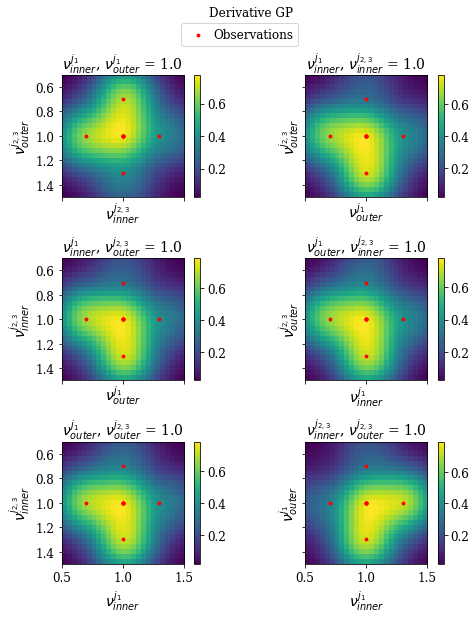

In [9]:
kernel = GPKernelDerAware(constant_value=0.1, length_scale=0.2, noise_level=1e-3, noise_level_dX=1)
gp_der = GaussianProcessRegressor(kernel=kernel, optimizer=None, random_state=123)
gp_der.fit(X=X_train, y=y_train, dX=X_train, dy=dy_train)
print(gp_der.kernel_)

mu_der, mse_der, uncert_der = get_gp_mu_mse_uncert(gp_der, X_test, y_test, batch_size=1024)
print("MSE: ", mse_der)
print("Uncert: ", uncert_der)

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = "12"
fig, ax = plt.subplots(3, 2, figsize=(8, 9), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.5, wspace=0.2)
hold_val = 1.0
axs = ax.ravel()
for i, comb in enumerate(combinations):
    ix = np.where((X_test[:, comb[0]] == hold_val) & (X_test[:, comb[1]] == hold_val))
    y_test_quad = mu_der[ix]
    axs[i].scatter(X_train[:, comb[0]], X_train[:, comb[1]], color='r', s=8, label='Observations')
    pcm = axs[i].imshow(y_test_quad.reshape(res, res), extent=[X_lower, X_upper, X_upper, X_lower])
    fig.colorbar(pcm, ax=axs[i])
    axs[i].set_title(
        "{}, {} = {}".format(params_labels[comb[0]], params_labels[comb[1]], hold_val), fontsize=14)
    var_params = [i for i in np.arange(4) if i not in comb]
    axs[i].set_xlabel(params_labels[var_params[0]], fontsize=14)
    axs[i].set_ylabel(params_labels[var_params[1]], fontsize=14)
    axs[i].set_xlim(0.5, 1.5)
    axs[i].set_ylim(1.5, 0.5)
handles, labels = axs[-1].get_legend_handles_labels()
fig.legend(handles=handles, labels=labels,
           loc=(0.38, 0.925), handletextpad=0.3, borderaxespad=0.4)
fig.text(0.45, 0.97, r'Derivative GP')